# Pillar 2: DFA Fundamentals & BEDI (Boomer Equity Displacement Index)

Tests the Pillar 2 thesis — Baby Boomers hold ~51% of U.S. household wealth and close to 70%
of public equities against a ~20% population share, and are entering the retirement
distribution phase — using real Fed Distributional Financial Accounts (DFA) data, no external
market data required.

**What this notebook builds:**
1. A **Boomer rotation signal** — their share of household equities minus their share of
   "safe" assets (deposits, bonds, annuities) — and whether it predicts subsequent wealth
   concentration or equity growth.
2. **BEDI** — a composite combining that rotation signal with the K-shape wealth-concentration
   gap, z-scored, with a structural-break test around 2019-2020.

**Files required (repo root, one directory up from this notebook):** the six `dfa-*.csv`
Distributional Financial Accounts files (age/generation/income/networth cuts, 1989:Q3-2026:Q1).

## 0 · Setup

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
pd.set_option("display.width", 140)
ROOT = Path("..")
OUT = Path("output"); OUT.mkdir(exist_ok=True)

EQUITY_COL = "Corporate equities and mutual fund shares"
SAFE_COLS = ["Deposits", "Money market fund shares",
             "U.S. government and municipal securities", "Corporate and foreign bonds", "Annuities"]
REAL_ESTATE_COL = "Real estate"

def parse_date(s):
    return pd.PeriodIndex(s.str.replace(":", "-"), freq="Q").to_timestamp(how="end").normalize()

def load_dfa(name):
    df = pd.read_csv(ROOT / name)
    df["Date"] = parse_date(df["Date"])
    return df


## 1 · Boomer rotation signal

BabyBoom's share of household-sector equities minus its share of "safe" assets (a combined
dollar bucket — see note below), and the quarter-over-quarter change in that spread: a real,
back-to-1989Q3 measure of whether Boomers are net rotating into or out of risk assets.

**Correctness note:** the safe-asset bucket's share must be computed by summing DOLLAR levels
across its component columns first, then taking one share of that combined total — summing
each component's own percentage share instead double-counts and can run past 100% (caught by
plotting the series and seeing it do exactly that during earlier development).

In [2]:
def generation_asset_shares(generation="BabyBoom"):
    df = load_dfa("dfa-generation-levels-detail.csv").copy()
    df["safe_assets_total"] = df[SAFE_COLS].sum(axis=1)
    cols = [EQUITY_COL, REAL_ESTATE_COL, "safe_assets_total"]
    totals = df.groupby("Date")[cols].transform("sum")
    shares = (df[cols] / totals * 100).add_suffix("_share_pct")
    out = pd.concat([df[["Date", "Category"]], shares], axis=1)
    out = out.rename(columns={"safe_assets_total_share_pct": "safe_share_pct"})
    return out[out["Category"] == generation].drop(columns="Category").set_index("Date").sort_index()

def rotation_signal(generation="BabyBoom"):
    shares = generation_asset_shares(generation)
    sig = pd.DataFrame(index=shares.index)
    sig["equity_share_pct"] = shares[f"{EQUITY_COL}_share_pct"]
    sig["safe_share_pct"] = shares["safe_share_pct"]
    sig["rotation_spread"] = sig["equity_share_pct"] - sig["safe_share_pct"]
    sig["rotation_spread_qoq_chg"] = sig["rotation_spread"].diff()
    sig["rotation_spread_yoy_chg"] = sig["rotation_spread"].diff(4)
    return sig

boomer = rotation_signal("BabyBoom")
boomer.tail()


,equity_share_pct,safe_share_pct,rotation_spread,rotation_spread_qoq_chg,rotation_spread_yoy_chg
Date,,,,,
2025-03-31,53.751483,51.067096,2.684387,0.150505,-0.553729
2025-06-30,53.546627,51.225491,2.321136,-0.363251,-0.571757
2025-09-30,53.262261,51.290601,1.971659,-0.349476,-0.401143
2025-12-31,53.216177,51.359384,1.856793,-0.114867,-0.677089
2026-03-31,53.876164,51.675078,2.201085,0.344292,-0.483302


## 2 · K-shape wealth concentration gap

Top 1% (TopPt1 + RemainingTop1) minus Bottom 50% share of net worth, directly from the DFA
net-worth-share cut — the same underlying data behind Pillar 4's chart.

In [3]:
def k_shape_intensity():
    df = load_dfa("dfa-networth-shares-detail.csv")
    wide = df.pivot(index="Date", columns="Category", values="Net worth")
    out = pd.DataFrame(index=wide.index)
    out["top1_share_pct"] = wide["TopPt1"] + wide["RemainingTop1"]
    out["bottom50_share_pct"] = wide["Bottom50"]
    out["k_shape_gap"] = out["top1_share_pct"] - out["bottom50_share_pct"]
    out["k_shape_gap_qoq_chg"] = out["k_shape_gap"].diff()
    return out.sort_index()

k_shape = k_shape_intensity()
k_shape.tail()


,top1_share_pct,bottom50_share_pct,k_shape_gap,k_shape_gap_qoq_chg
Date,,,,
2025-03-31,30.9,2.5,28.4,-0.1
2025-06-30,31.2,2.5,28.7,0.3
2025-09-30,31.6,2.5,29.1,0.4
2025-12-31,31.8,2.5,29.3,0.2
2026-03-31,31.6,2.5,29.1,-0.2


## 3 · Aggregate equity growth proxy

Stock prices themselves are blocked in this environment (Yahoo Finance/FRED wall, confirmed
directly). QoQ growth in total household-sector equity holdings is a real, DFA-derived stand-in
— it conflates price return with net flows, so treat it as directional, not a clean return.

In [4]:
def aggregate_equity_growth():
    df = load_dfa("dfa-generation-levels-detail.csv")
    total = df.groupby("Date")[EQUITY_COL].sum().sort_index()
    return total.pct_change().rename("agg_equity_qoq_growth")

eq_growth = aggregate_equity_growth()
eq_growth.tail()


Date
2025-03-31   -0.019098
2025-06-30    0.080628
2025-09-30    0.075549
2025-12-31    0.025059
2026-03-31   -0.023807
Name: agg_equity_qoq_growth, dtype: float64

## 4 · Chart: Boomer rotation vs. K-shape gap

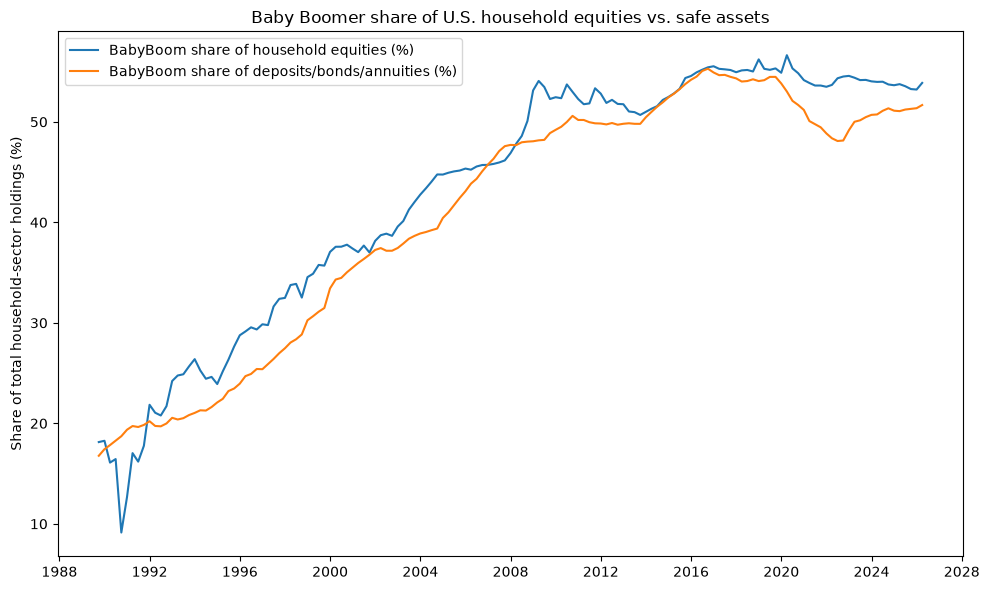

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(boomer.index, boomer["equity_share_pct"], label="BabyBoom share of household equities (%)")
plt.plot(boomer.index, boomer["safe_share_pct"], label="BabyBoom share of deposits/bonds/annuities (%)")
plt.title("Baby Boomer share of U.S. household equities vs. safe assets")
plt.ylabel("Share of total household-sector holdings (%)")
plt.legend(); plt.tight_layout()
plt.savefig(OUT / "dfa_boomer_rotation.png", dpi=150); plt.show()


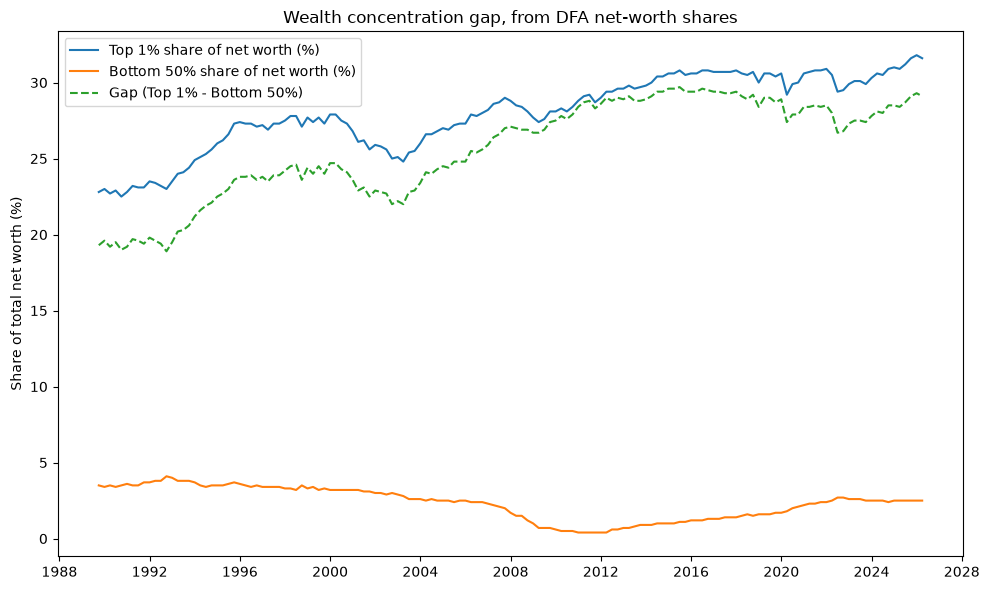

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(k_shape.index, k_shape["top1_share_pct"], label="Top 1% share of net worth (%)")
plt.plot(k_shape.index, k_shape["bottom50_share_pct"], label="Bottom 50% share of net worth (%)")
plt.plot(k_shape.index, k_shape["k_shape_gap"], label="Gap (Top 1% - Bottom 50%)", linestyle="--")
plt.title("Wealth concentration gap, from DFA net-worth shares")
plt.ylabel("Share of total net worth (%)")
plt.legend(); plt.tight_layout()
plt.savefig(OUT / "dfa_k_shape_gap.png", dpi=150); plt.show()


## 5 · Predictive test: does Boomer rotation lead K-shape or equity growth?

Regresses each outcome's QoQ change on 1-4 quarter lags of the rotation signal's QoQ change,
HAC standard errors — this is the real alpha test, computable entirely from the DFA data.

In [7]:
def lagged_regression(y, x, max_lag=4, hac=3):
    df = pd.DataFrame({"y": y, "x": x})
    cols = []
    for lag in range(1, max_lag + 1):
        c = f"x_lag{lag}"; df[c] = df["x"].shift(lag); cols.append(c)
    df = df.dropna()
    X = sm.add_constant(df[cols])
    return sm.OLS(df["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": hac})

panel = boomer[["rotation_spread_qoq_chg"]].join(k_shape[["k_shape_gap_qoq_chg"]], how="inner") \
             .join(eq_growth, how="inner").dropna()
print(f"Panel: {len(panel)} quarterly observations, {panel.index.min().date()} -> {panel.index.max().date()}\n")

for outcome in ["k_shape_gap_qoq_chg", "agg_equity_qoq_growth"]:
    model = lagged_regression(panel[outcome], panel["rotation_spread_qoq_chg"])
    print(f"=== {outcome} ~ lags of BabyBoom rotation_spread_qoq_chg ===")
    print(model.summary().tables[1])
    print(f"Joint F-test: F={model.fvalue:.3f}, p={model.f_pvalue:.4f}\n")


Panel: 146 quarterly observations, 1989-12-31 -> 2026-03-31

=== k_shape_gap_qoq_chg ~ lags of BabyBoom rotation_spread_qoq_chg ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0716      0.031      2.289      0.022       0.010       0.133
x_lag1        -0.0162      0.022     -0.744      0.457      -0.059       0.027
x_lag2        -0.0173      0.026     -0.662      0.508      -0.068       0.034
x_lag3         0.0019      0.023      0.083      0.934      -0.043       0.046
x_lag4         0.0378      0.020      1.847      0.065      -0.002       0.078
Joint F-test: F=2.618, p=0.0377

=== agg_equity_qoq_growth ~ lags of BabyBoom rotation_spread_qoq_chg ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0281      0.007      3.951      0.

### 5.1 Robustness sweep across cohorts and lag lengths

A specification significant at only one lag length is a red flag for a mined result, not a
real signal — so this sweeps 8 cohort cuts (4 generations, 4 age bands) × 2 lag lengths × 2
outcomes = 32 combinations.

In [8]:
def age_rotation_signal(age_bucket):
    df = load_dfa("dfa-age-levels-detail.csv").copy()
    df["safe_assets_total"] = df[SAFE_COLS].sum(axis=1)
    cols = [EQUITY_COL, "safe_assets_total"]
    totals = df.groupby("Date")[cols].transform("sum")
    shares = df[cols] / totals * 100
    df["equity_share_pct"] = shares[EQUITY_COL]
    df["safe_share_pct"] = shares["safe_assets_total"]
    out = df[df["Category"] == age_bucket].set_index("Date").sort_index()
    out["rotation_spread"] = out["equity_share_pct"] - out["safe_share_pct"]
    out["rotation_spread_qoq_chg"] = out["rotation_spread"].diff()
    return out[["equity_share_pct", "safe_share_pct", "rotation_spread", "rotation_spread_qoq_chg"]]

rows = []
cuts = {f"generation:{g}": rotation_signal(g) for g in ["BabyBoom", "GenX", "Millennial", "Silent"]}
for bucket in ["age70plus", "age55to69", "age40to54", "ageunder40"]:
    cuts[f"age:{bucket}"] = age_rotation_signal(bucket)

for name, sig in cuts.items():
    p = sig.join(k_shape, how="inner").join(eq_growth, how="inner").dropna()
    trend_corr = pd.Series(range(len(p)), index=p.index).corr(p["rotation_spread"])
    level_corr_k = p["rotation_spread"].corr(p["k_shape_gap"])
    for max_lag in [2, 4]:
        m_k = lagged_regression(p["k_shape_gap_qoq_chg"], p["rotation_spread_qoq_chg"], max_lag=max_lag)
        m_eq = lagged_regression(p["agg_equity_qoq_growth"], p["rotation_spread_qoq_chg"], max_lag=max_lag)
        rows.append({"cohort_cut": name, "max_lag": max_lag,
                     "corr(rotation, calendar_time)": round(trend_corr, 3),
                     "corr(rotation, k_shape) [level]": round(level_corr_k, 3),
                     "k_shape F p-value": round(m_k.f_pvalue, 3), "k_shape R2": round(m_k.rsquared, 3),
                     "eq_growth F p-value": round(m_eq.f_pvalue, 3), "eq_growth R2": round(m_eq.rsquared, 3)})

results = pd.DataFrame(rows).set_index(["cohort_cut", "max_lag"])
results.to_csv(OUT / "dfa_predictive_test_results.csv")
n_tests = len(results) * 2
n_sig = (results.filter(like="F p-value") < 0.05).sum().sum()
print(results.to_string())
print(f"\n{n_sig} of {n_tests} specification/outcome combinations clear p<0.05 -- "
      f"consistent with the ~{0.05*n_tests:.1f} expected by chance alone with no true effect.")


                               corr(rotation, calendar_time)  corr(rotation, k_shape) [level]  k_shape F p-value  k_shape R2  eq_growth F p-value  eq_growth R2
cohort_cut            max_lag                                                                                                                                  
generation:BabyBoom   2                                0.039                            0.003              0.708       0.004                0.716         0.005
                      4                                0.039                            0.003              0.081       0.025                0.017         0.061
generation:GenX       2                               -0.243                           -0.022              0.391       0.006                0.618         0.018
                      4                               -0.243                           -0.022              0.176       0.020                0.128         0.041
generation:Millennial 2                 

**Honest read:** this linear, single-cohort rotation signal does not show robust evidence of
predicting either wealth-concentration shifts or aggregate equity growth at 1-4 quarter
horizons — a legitimate research finding, not a dead end. It doesn't falsify the broader
Pillar 2 thesis (Boomer wealth/equity concentration is real); it means this particular linear
construction isn't demonstrated to carry exploitable predictive content on its own.

## 6 · BEDI — combining the two signals into one composite

BEDI rises when Boomers are de-risking (falling rotation_spread) **and** concentration is
widening (rising k_shape_gap) at the same time. Built two ways: full-sample z-score
(descriptive only — has look-ahead) and an expanding/point-in-time version (no look-ahead,
safe for anything predictive). PCA via direct SVD rather than adding scikit-learn as a
dependency for one principal component.

In [9]:
COMPONENT_SIGNS = {"rotation_spread": -1.0, "k_shape_gap": 1.0}  # rotation falls as Boomers de-risk; BEDI should rise

def raw_components():
    return boomer[["rotation_spread"]].join(k_shape[["k_shape_gap"]], how="inner").sort_index()

def first_pc(X):
    Xc = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    scores = U[:, 0] * S[0]
    return scores, Vt[0], (S[0]**2) / (S**2).sum()

def build_bedi_full_sample():
    raw = raw_components()
    z = pd.DataFrame({c: COMPONENT_SIGNS[c] * (raw[c] - raw[c].mean()) / raw[c].std() for c in raw.columns})
    out = pd.DataFrame(index=raw.index)
    out["z_rotation"], out["z_k_shape"] = z["rotation_spread"], z["k_shape_gap"]
    out["BEDI_equal_weight"] = z.mean(axis=1)
    scores, loadings, evr = first_pc(z[["rotation_spread", "k_shape_gap"]].values)
    scores = pd.Series(scores, index=z.index)
    if scores.corr(out["BEDI_equal_weight"]) < 0:
        scores, loadings = -scores, -loadings
    out["BEDI_pca"] = scores
    return out, pd.Series(loadings, index=["rotation_spread", "k_shape_gap"]), evr

def build_bedi_expanding(min_periods=20):
    raw = raw_components()
    z = pd.DataFrame(index=raw.index)
    for c in raw.columns:
        em, es = raw[c].expanding(min_periods=min_periods).mean(), raw[c].expanding(min_periods=min_periods).std()
        z[c] = COMPONENT_SIGNS[c] * (raw[c] - em) / es
    z = z.dropna()
    out = pd.DataFrame(index=z.index)
    out["z_rotation"], out["z_k_shape"] = z["rotation_spread"], z["k_shape_gap"]
    out["BEDI_equal_weight"] = z.mean(axis=1)
    pca_vals = []
    for i in range(min_periods, len(z) + 1):
        window = z.iloc[:i][["rotation_spread", "k_shape_gap"]].values
        scores, _, _ = first_pc(window)
        val = scores[-1]
        if pd.Series(scores, index=z.index[:i]).corr(out["BEDI_equal_weight"].iloc[:i]) < 0:
            val = -val
        pca_vals.append(val)
    out["BEDI_pca"] = pd.Series(pca_vals, index=z.index[min_periods - 1:])
    return out.dropna()

full, loadings, evr = build_bedi_full_sample()
exp = build_bedi_expanding()
full.tail()


,z_rotation,z_k_shape,BEDI_equal_weight,BEDI_pca
Date,,,,
2025-03-31,-0.191948,0.845940,0.326996,-0.733898
2025-06-30,-0.034097,0.938511,0.452207,-0.687737
2025-09-30,0.117768,1.061938,0.589853,-0.667629
2025-12-31,0.167684,1.123652,0.645668,-0.675972
2026-03-31,0.018071,1.061938,0.540005,-0.738125


### 6.1 Component co-movement check

In [10]:
raw = raw_components()
corr_components = raw["rotation_spread"].corr(raw["k_shape_gap"])
print(f"corr(rotation_spread, k_shape_gap), raw levels, full sample: {corr_components:.3f}")
print("Pillar 1's three indicators correlated 0.87-0.96 with each other (a real common factor).")
print("These two components correlate far weaker -- PCA weighting here reveals there mostly")
print("isn't a dominant shared driver, rather than confirming one.")
print(f"corr(BEDI_equal_weight, BEDI_pca), full-sample: {full['BEDI_equal_weight'].corr(full['BEDI_pca']):.3f}")
print(f"corr(BEDI_equal_weight, BEDI_pca), expanding:   {exp['BEDI_equal_weight'].corr(exp['BEDI_pca']):.3f}")
print(f"PCA explained variance ratio (full-sample): {evr:.3f} (50% = no dominant shared axis)")


corr(rotation_spread, k_shape_gap), raw levels, full sample: 0.064
Pillar 1's three indicators correlated 0.87-0.96 with each other (a real common factor).
These two components correlate far weaker -- PCA weighting here reveals there mostly
isn't a dominant shared driver, rather than confirming one.
corr(BEDI_equal_weight, BEDI_pca), full-sample: 0.000
corr(BEDI_equal_weight, BEDI_pca), expanding:   0.719
PCA explained variance ratio (full-sample): 0.532 (50% = no dominant shared axis)


## 7 · BEDI charts

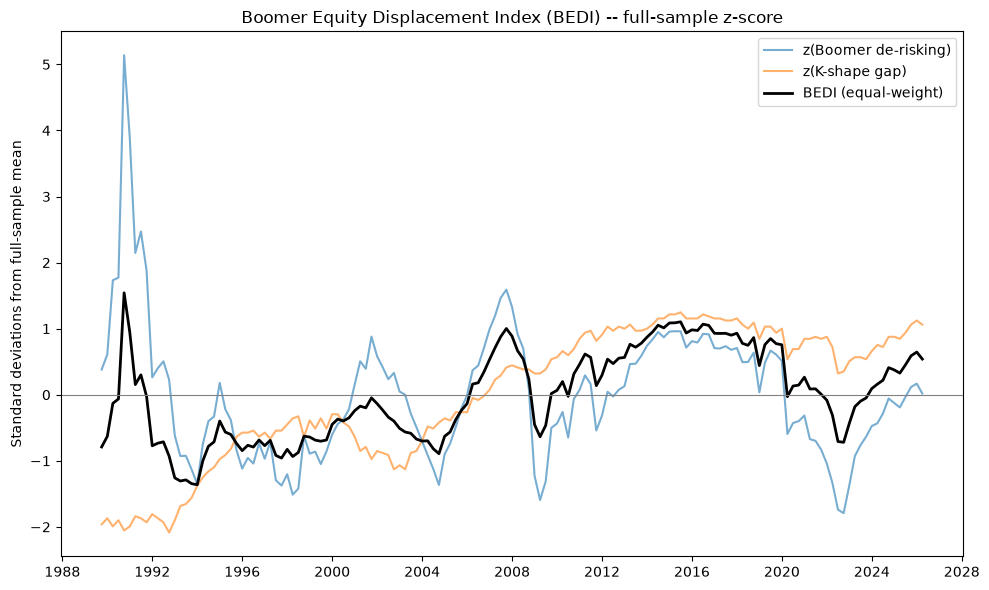

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(full.index, full["z_rotation"], label="z(Boomer de-risking)", alpha=0.6)
plt.plot(full.index, full["z_k_shape"], label="z(K-shape gap)", alpha=0.6)
plt.plot(full.index, full["BEDI_equal_weight"], label="BEDI (equal-weight)", linewidth=2, color="black")
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Boomer Equity Displacement Index (BEDI) -- full-sample z-score")
plt.ylabel("Standard deviations from full-sample mean"); plt.legend(); plt.tight_layout()
plt.savefig(OUT / "bedi_full_sample.png", dpi=150); plt.show()


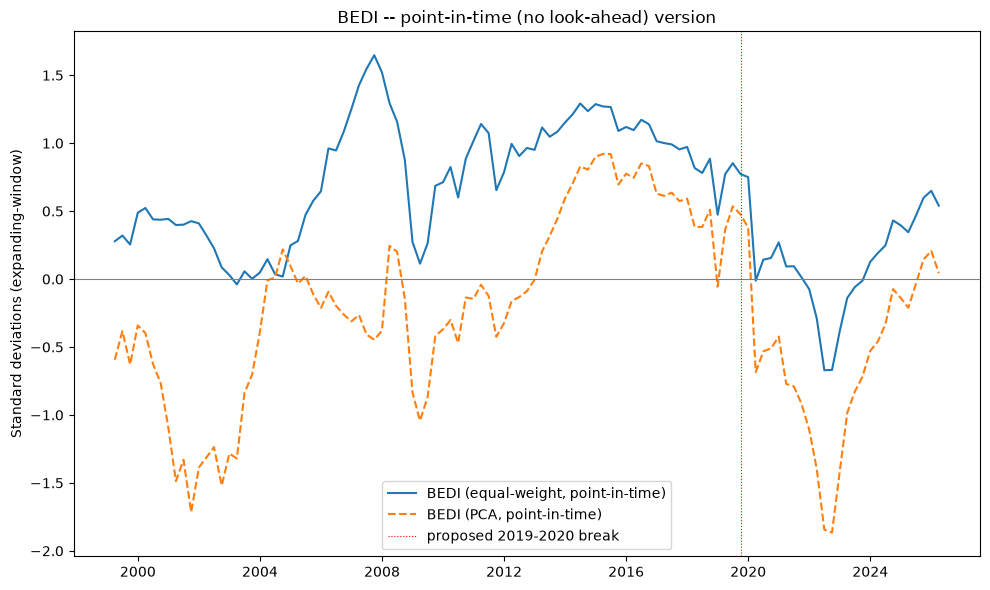

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(exp.index, exp["BEDI_equal_weight"], label="BEDI (equal-weight, point-in-time)")
plt.plot(exp.index, exp["BEDI_pca"], label="BEDI (PCA, point-in-time)", linestyle="--")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(pd.Timestamp("2019-10-01"), color="red", linewidth=0.8, linestyle=":", label="proposed 2019-2020 break")
plt.title("BEDI -- point-in-time (no look-ahead) version")
plt.ylabel("Standard deviations (expanding-window)"); plt.legend(); plt.tight_layout()
plt.savefig(OUT / "bedi_expanding.png", dpi=150); plt.show()


## 8 · Structural break test (2019-2020)

The combined model (level-shift dummy + trend-interaction together) can show a significant
joint F-test while both individual coefficients look insignificant — a multicollinearity
artifact (`post` and `t_post` correlate ~0.998 here), not evidence of "no break." Level-shift
and trend-change are also fit separately, each cleanly identified on its own.

In [13]:
def structural_break_test(bedi, break_date="2019-10-01"):
    df = pd.DataFrame({"y": bedi})
    df["t"] = range(len(df))
    df["post"] = (df.index >= pd.Timestamp(break_date)).astype(int)
    df["t_post"] = df["t"] * df["post"]
    restricted = sm.OLS(df["y"], sm.add_constant(df[["t"]])).fit()
    combined = sm.OLS(df["y"], sm.add_constant(df[["t", "post", "t_post"]])).fit()
    level_only = sm.OLS(df["y"], sm.add_constant(df[["t", "post"]])).fit()
    trend_only = sm.OLS(df["y"], sm.add_constant(df[["t", "t_post"]])).fit()
    f_test = combined.compare_f_test(restricted)
    return combined, level_only, trend_only, f_test, df["post"].corr(df["t_post"])

combined, level_only, trend_only, f_test, collin = structural_break_test(full["BEDI_equal_weight"])
print(f"Joint F-test: F={f_test[0]:.3f}, p={f_test[1]:.6f}")
print(f"corr(post, t_post) in the combined model: {collin:.3f} -- combined model's individual "
      "coefficients are NOT reliable on their own because of this; see level_only/trend_only.\n")
print("--- Level-shift-only model (cleanly identified) ---")
print(level_only.summary().tables[1])
print("\n--- Trend-slope-change-only model (cleanly identified) ---")
print(trend_only.summary().tables[1])


Joint F-test: F=27.432, p=0.000000
corr(post, t_post) in the combined model: 0.998 -- combined model's individual coefficients are NOT reliable on their own because of this; see level_only/trend_only.

--- Level-shift-only model (cleanly identified) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9514      0.085    -11.173      0.000      -1.120      -0.783
t              0.0155      0.001     12.642      0.000       0.013       0.018
post          -1.0125      0.136     -7.432      0.000      -1.282      -0.743

--- Trend-slope-change-only model (cleanly identified) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9539      0.085    -11.159      0.000      -1.123      -0.785
t              0.0155      0.001     12.596      0.000

**Both point the opposite sign from "the retirement wave accelerated BEDI"** — a level
*drop* and trend *deceleration* at 2019:Q4, not an acceleration. The chart above confirms this
visually: BEDI drops sharply starting 2020, bottoms near a deep trough around 2022-23, and
still sits below its pre-2020 peak as of the latest quarter.

## Summary

- **Predictive test (Section 5):** null result, honestly reported — no robust evidence this
  linear rotation signal predicts wealth concentration or equity growth, across 32
  specifications.
- **BEDI's two components barely correlate** (+0.064 full sample) — very different from
  Pillar 1's three indicators (0.87-0.96), so PCA weighting doesn't confirm a dominant shared
  driver here.
- **Structural break is real but sign-reversed** from the "accelerating retirement wave"
  narrative — a level drop and deceleration in 2019-2020, not an acceleration.
- **Still needed for a genuine alpha test:** real ETF/security returns to test whether any of
  these signals predict tradeable P&L, not just other fundamentals series — see
  `02_ETF_Long_Short_Backtest.ipynb`.